# Convolution of 2 identical Sinc ftns

$$
f_3(t) = \int_{-\infty}^{\infty} f_1(\tau)f_2(t-\tau) d\tau
$$

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
import scipy.integrate as integrate

def H(t):
    return np.heaviside(t, 1)

In [4]:
p = 2 # scaling
tt_vals = np.linspace(-3, 3, 1000)

def integrand(tau, t):
    return np.sinc(p*tau) * np.sinc(p*(t - tau))

In [5]:
f3 = []
for t in tt_vals:
    f3.append(integrate.quad(integrand, -np.inf, np.inf, args=(t))[0])

/var/folders/wv/3mv73kyx13x52f1hzz303m740000gn/T/ipykernel_87319/3647791905.py:3: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  f3.append(integrate.quad(integrand, -np.inf, np.inf, args=(t))[0])


/var/folders/wv/3mv73kyx13x52f1hzz303m740000gn/T/ipykernel_87319/3647791905.py:3: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  f3.append(integrate.quad(integrand, -np.inf, np.inf, args=(t))[0])


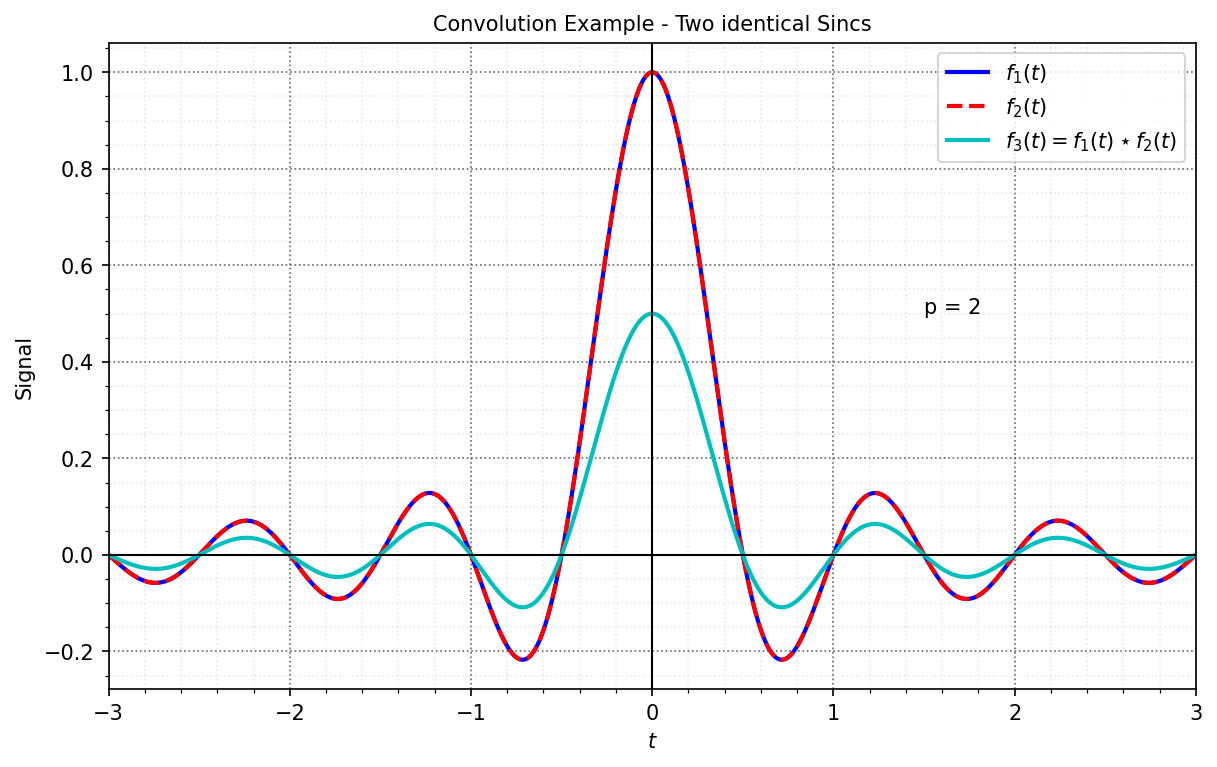

In [6]:
fig = plt.figure(1,figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(tt_vals, np.sinc(p*tt_vals),'b-',lw=2,label='$f_1(t)$')
plt.plot(tt_vals, np.sinc(p*tt_vals),'r--',label='$f_2(t)$')
plt.plot(tt_vals, f3,'c-',label=r'$f_3(t)=f_1(t) \star f_2(t)$')
bm.nicegrid()
plt.text(1+1/p,1/p,'p = '+str(p))
plt.legend()
plt.ylabel("Signal")
plt.xlabel("$t$")
plt.title('Convolution Example - Two identical Sincs')
plt.show()

## Explanation using Material from Topic 7

* Goal: compute ${\tt sinc}(pt) \star {\tt sinc}(pt)$ - calculation is doable, but clearly quite difficult to computate directly.

* Approach: know that ${\tt sinc}(pt) \Leftrightarrow \frac{1}{p} {\tt rect} (p f)$, so now use Convolution $\Leftrightarrow$ Multiplication

$${\tt sinc}(pt) \star {\tt sinc}(pt) \Leftrightarrow \frac{1}{p} {\tt rect} (p f) \cdot \frac{1}{p} {\tt rect} (p f)
$$

* Recall special property that ${\tt rect} (p f) \cdot {\tt rect} (p f) = {\tt rect} (p f)$, so we have that the righthandside becomes
$$
\frac{1}{p} {\tt rect} (p f) \cdot \frac{1}{p} {\tt rect} (p f) \Rightarrow
\left(\frac{1}{p}\right)^2 {\tt rect}^2 (p f) \Rightarrow
\left(\frac{1}{p}\right)^2 {\tt rect} (p f) $$

* Thus it follows that $ {\tt sinc}(pt) \star {\tt sinc}(pt) \Leftrightarrow \left(\frac{1}{p}\right)^2 {\tt rect} (p f) $ 

* Now note that since
${\tt sinc}(pt) \Leftrightarrow \frac{1}{p} {\tt rect} (p f)$
then
$$\Rightarrow \left(\frac{1}{p}\right) {\tt sinc}(pt) 
\Leftrightarrow \left(\frac{1}{p}\right) \left\{ \left(\frac{1}{p}\right) {\tt rect} (p f) \right\}
= \left(\frac{1}{p}\right)^2 {\tt rect} (p f) 
$$

* Since the righthand sides of the two expressions are equal, we have that
$$
{\tt sinc}(pt) \star {\tt sinc}(pt) = \left(\frac{1}{p}\right) {\tt sinc}(pt) 
$$

In [7]:
p1 = 2 # scaling
p2 = 4 # scaling
tt_vals = np.linspace(-3, 3, 1000)

def integrand(tau, t):
    return np.sinc(p1*tau) * np.sinc(p2*(t - tau))

In [8]:
f3 = []
for t in tt_vals:
    f3.append(integrate.quad(integrand, -np.inf, np.inf, args=(t))[0])

/var/folders/wv/3mv73kyx13x52f1hzz303m740000gn/T/ipykernel_87319/3647791905.py:3: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  f3.append(integrate.quad(integrand, -np.inf, np.inf, args=(t))[0])
/var/folders/wv/3mv73kyx13x52f1hzz303m740000gn/T/ipykernel_87319/3647791905.py:3: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  f3.append(integrate.quad(integrand, -np.inf, np.inf, args=(t))[0])


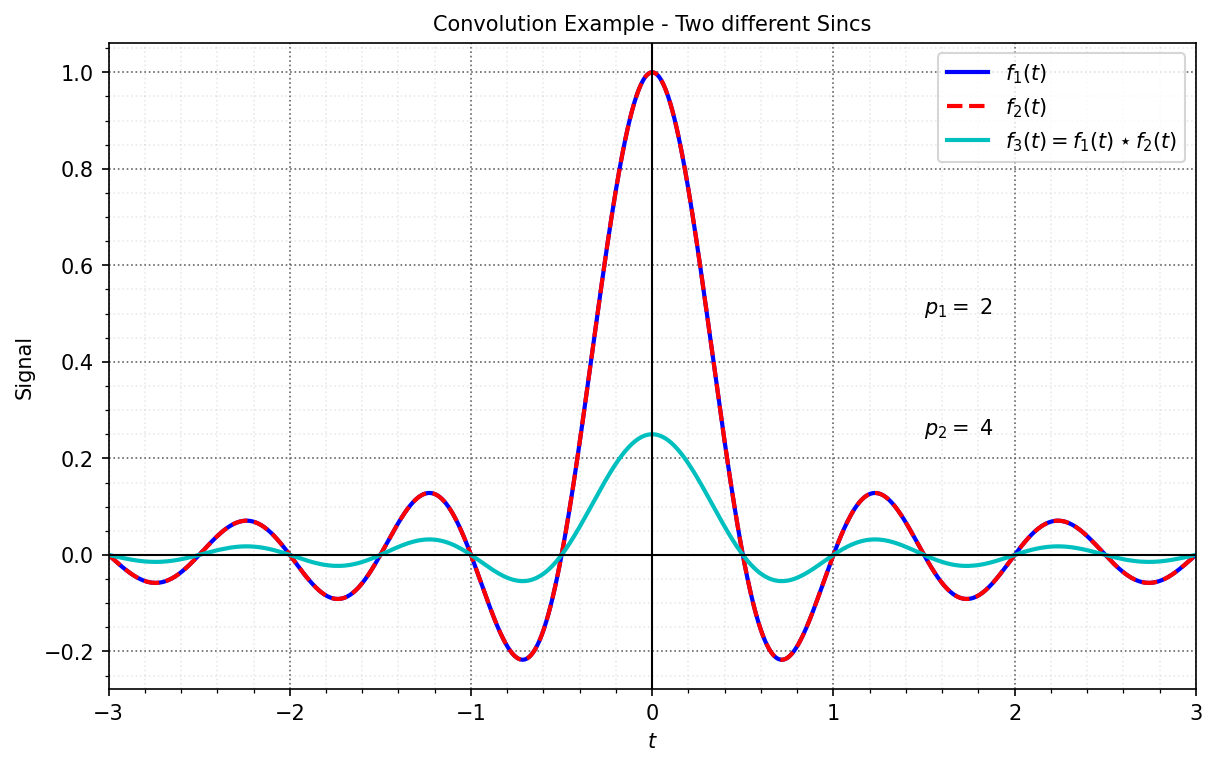

In [9]:
fig = plt.figure(1,figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(tt_vals, np.sinc(p*tt_vals),'b-',lw=2,label='$f_1(t)$')
plt.plot(tt_vals, np.sinc(p*tt_vals),'r--',label='$f_2(t)$')
plt.plot(tt_vals, f3,'c-',label=r'$f_3(t)=f_1(t) \star f_2(t)$')
bm.nicegrid()
plt.text(1+1/p1,1/p1,r'$p_1 =$ '+str(p1))
plt.text(1+1/p1,1/p2,r'$p_2 =$ '+str(p2))
plt.legend()
plt.ylabel("Signal")
plt.xlabel("$t$")
plt.title('Convolution Example - Two different Sincs')
plt.show()

We have
$$
\operatorname{sinc}(pt)
\;\Longleftrightarrow\;
\frac{1}{|p|}\operatorname{rect}\left(\frac{f}{p}\right).
$$

Thus
$$
\operatorname{sinc}(p_1t)*\operatorname{sinc}(p_2t) \Leftrightarrow \frac{1}{|p_1p_2|}
\operatorname{rect}\left(\frac{f}{p_1}\right)
\operatorname{rect}\left(\frac{f}{p_2}\right).
$$
The product of the two rectangular functions is the narrower rectangle, so the righthand side becomes
$$
\frac{1}{|p_1p_2|}
\operatorname{rect}\left(\frac{f}{p_{\min}}\right),
$$
where
$$
p_{\min}=\min(|p_1|,|p_2|).
$$

Taking the inverse Fourier transform gives
$$
\boxed{
\operatorname{sinc}(p_1t)*\operatorname{sinc}(p_2t)
=
\frac{p_{\min}}{|p_1p_2|}
\operatorname{sinc}(p_{\min}t)
}
$$

For $p_1>0$ and $p_2>0$, this becomes
$$
\boxed{
\operatorname{sinc}(p_1t)*\operatorname{sinc}(p_2t)
=
\frac{\min(p_1,p_2)}{p_1p_2}
\operatorname{sinc}\left(\min(p_1,p_2)t\right)
}
$$